# Phase 2: Hypothesis Testing

**Project:** Credit Default Risk Modeling  
**Phase:** 2 — Statistical Significance of Features  

## Why Hypothesis Testing?

WoE/IV told us **which features are predictive**.  
Hypothesis Testing tells us **whether that predictive power is statistically real** — or just random noise.

This is what separates a data scientist from someone who just runs models.

---

## The Framework (Always Follow This)

Every test follows this structure:

1. **H₀ (Null Hypothesis):** No difference between groups / no relationship
2. **H₁ (Alternative Hypothesis):** There IS a significant difference
3. **Significance Level:** α = 0.05 (5% false positive tolerance)
4. **Test Statistic + p-value**
5. **Decision:** Reject H₀ if p < 0.05
6. **Effect Size:** HOW big is the difference (not just IF it exists)
7. **Business Interpretation**

---

## Which Test for Which Feature Type?

| Feature Type | Test | Why |
|---|---|---|
| Numeric (non-normal) | **Mann-Whitney U** | Compares distributions without assuming normality |
| Categorical | **Chi-Square** | Tests independence between category and default |
| Numeric (normal) | **t-test** | Compares means — but we verify normality first |
| 3+ groups | **Kruskal-Wallis** | Non-parametric ANOVA alternative |

## 1 Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import (
    mannwhitneyu, chi2_contingency, kruskal,
    normaltest, shapiro, ttest_ind
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

ALPHA = 0.05   # significance level
print(f'Significance level α = {ALPHA}')
print('Libraries loaded')

Significance level α = 0.05
Libraries loaded


## 2 Load & Prepare Data

In [4]:
data = pd.read_csv('/home/vidit/Public/Project/Customer Churn Prediction/Data/german_credit_data.csv')

column_mapping = {
    'laufkont':'checking_account', 'laufzeit':'duration_months',
    'moral':'credit_history',      'verw':'purpose',
    'hoehe':'credit_amount',       'sparkont':'savings_account',
    'beszeit':'employment_years',  'rate':'installment_rate',
    'famges':'personal_status',    'buerge':'other_debtors',
    'wohnzeit':'residence_years',  'verm':'property',
    'alter':'age',                 'weitkred':'other_installments',
    'wohn':'housing',              'bishkred':'existing_credits',
    'beruf':'job',                 'pers':'dependents',
    'telef':'telephone',           'gastarb':'foreign_worker',
    'kredit':'target'
}
data.rename(columns=column_mapping, inplace=True)

raw_vals = sorted(data['target'].unique())
if set(raw_vals) == {1, 2}:
    data['target'] = data['target'].map({1: 0, 2: 1})
elif set(raw_vals) == {0, 1}:
    data['target'] = data['target'].map({1: 0, 0: 1})

# Split into Good vs Default groups
good    = data[data['target'] == 0]
default = data[data['target'] == 1]

print(f'Shape: {data.shape}')
print(f'Good customers   : {len(good)}')
print(f'Default customers: {len(default)}')
print(f'Default Rate     : {data["target"].mean()*100:.1f}%')
print('Data ready')

Shape: (1000, 21)
Good customers   : 700
Default customers: 300
Default Rate     : 30.0%
Data ready


In [5]:
# Selected features from Phase 1 (IV >= 0.02)
numeric_selected = [
    'duration_months', 'credit_amount', 'age',
    'installment_rate', 'residence_years'
]

categorical_selected = [
    'checking_account', 'credit_history', 'purpose',
    'savings_account', 'employment_years', 'personal_status',
    'other_debtors', 'property', 'other_installments',
    'housing', 'foreign_worker'
]

print(f'Numeric features to test   : {len(numeric_selected)}')
print(f'Categorical features to test: {len(categorical_selected)}')

Numeric features to test   : 5
Categorical features to test: 11


## 3 Normality Check — Which Test Should We Use?

Before choosing between t-test and Mann-Whitney U, we must check if numeric features are normally distributed.

**Shapiro-Wilk Test:**
- H₀: Data is normally distributed
- If p < 0.05 → reject normality → use **Mann-Whitney U**
- If p ≥ 0.05 → normality holds → can use **t-test**

In [6]:
print('=== Shapiro-Wilk Normality Test ===\n')
print(f'{"Feature":<22} {"W-stat":>8} {"p-value":>10} {"Normal?":>10} {"→ Use Test"}')
print('-' * 65)

normality_results = {}
for col in numeric_selected:
    # Shapiro-Wilk (use sample if large)
    sample = data[col].sample(min(len(data), 300), random_state=42)
    stat, p = shapiro(sample)
    is_normal = p >= ALPHA
    test_to_use = 't-test' if is_normal else 'Mann-Whitney U'
    normality_results[col] = is_normal
    print(f'{col:<22} {stat:>8.4f} {p:>10.4f} {str(is_normal):>10}   → {test_to_use}')

print('\n💡 Most financial data is non-normal → Mann-Whitney U is safer choice')

=== Shapiro-Wilk Normality Test ===

Feature                  W-stat    p-value    Normal? → Use Test
-----------------------------------------------------------------
duration_months          0.8780     0.0000      False   → Mann-Whitney U
credit_amount            0.7569     0.0000      False   → Mann-Whitney U
age                      0.9205     0.0000      False   → Mann-Whitney U
installment_rate         0.7863     0.0000      False   → Mann-Whitney U
residence_years          0.8147     0.0000      False   → Mann-Whitney U

💡 Most financial data is non-normal → Mann-Whitney U is safer choice


## 4 Distribution Plots — Visual Normality Check

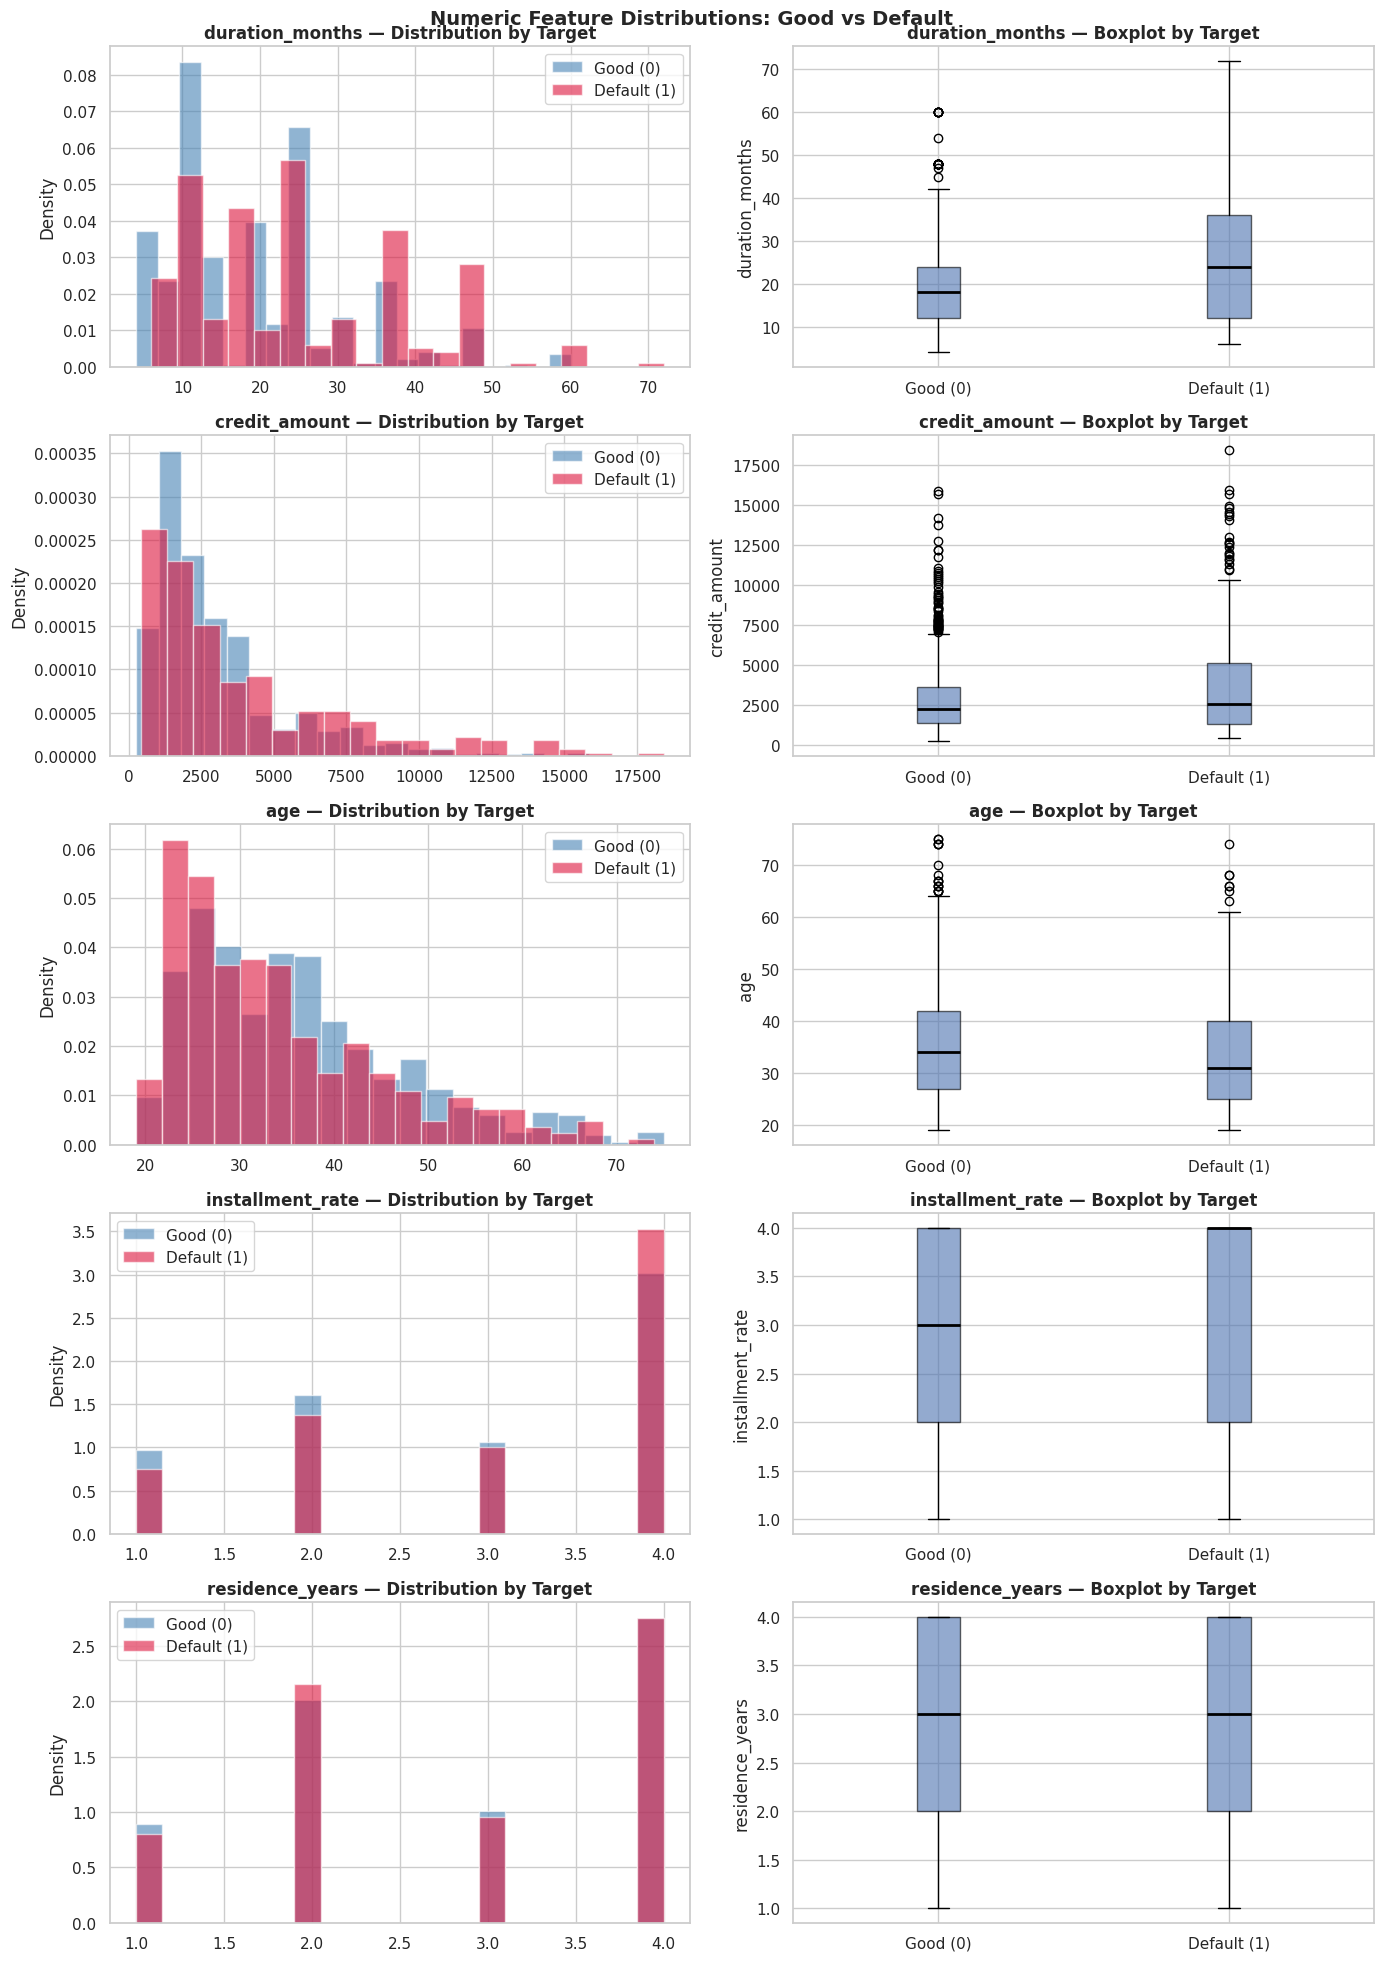

In [7]:
fig, axes = plt.subplots(len(numeric_selected), 2, figsize=(14, 4*len(numeric_selected)))

for i, col in enumerate(numeric_selected):
    g = good[col]
    d = default[col]

    # Histogram overlay
    axes[i][0].hist(g, bins=20, alpha=0.6, color='steelblue', label='Good (0)', density=True)
    axes[i][0].hist(d, bins=20, alpha=0.6, color='crimson',   label='Default (1)', density=True)
    axes[i][0].set_title(f'{col} — Distribution by Target', fontweight='bold')
    axes[i][0].set_ylabel('Density')
    axes[i][0].legend()

    # Box plot
    axes[i][1].boxplot([g, d], labels=['Good (0)', 'Default (1)'],
                       patch_artist=True,
                       boxprops=dict(alpha=0.6),
                       medianprops=dict(color='black', linewidth=2))
    axes[i][1].set_title(f'{col} — Boxplot by Target', fontweight='bold')
    axes[i][1].set_ylabel(col)

plt.suptitle('Numeric Feature Distributions: Good vs Default', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5 Mann-Whitney U Test — Numeric Features

**What it tests:** Are the distributions of a numeric feature significantly different between Good and Default customers?

**Effect Size — Rank-Biserial Correlation (r):**
$$r = 1 - \frac{2U}{n_1 \times n_2}$$

| |r| | Effect Size |
|---|---|
| < 0.1 | Negligible |
| 0.1 – 0.3 | Small |
| 0.3 – 0.5 | Medium |
| > 0.5 | Large |

In [8]:
def effect_size_label(r):
    r = abs(r)
    if r < 0.1:   return 'Negligible'
    elif r < 0.3: return 'Small'
    elif r < 0.5: return 'Medium'
    else:         return 'Large'


print('=== Mann-Whitney U Test — Numeric Features ===\n')
print(f'H₀: Distribution is the same for Good and Default customers')
print(f'H₁: Distributions are significantly different')
print(f'α  = {ALPHA}\n')
print(f'{"Feature":<22} {"U-stat":>10} {"p-value":>10} {"Reject H₀?":>12} {"Effect r":>10} {"Size"}')
print('-' * 80)

mw_results = []
for col in numeric_selected:
    g = good[col].dropna()
    d = default[col].dropna()
    u_stat, p_val = mannwhitneyu(g, d, alternative='two-sided')

    # Rank-biserial correlation (effect size)
    n1, n2 = len(g), len(d)
    r = 1 - (2 * u_stat) / (n1 * n2)

    reject = p_val < ALPHA
    mw_results.append({
        'Feature': col, 'U-stat': round(u_stat,2),
        'p-value': round(p_val,4), 'Reject H0': reject,
        'Effect r': round(r,4), 'Effect Size': effect_size_label(r)
    })
    print(f'{col:<22} {u_stat:>10.1f} {p_val:>10.4f} {str(reject):>12} {r:>10.4f}   {effect_size_label(r)}')

mw_df = pd.DataFrame(mw_results)
print(f'\n Features where H₀ rejected (p < {ALPHA}):')
print(mw_df[mw_df['Reject H0']]['Feature'].tolist())

=== Mann-Whitney U Test — Numeric Features ===

H₀: Distribution is the same for Good and Default customers
H₁: Distributions are significantly different
α  = 0.05

Feature                    U-stat    p-value   Reject H₀?   Effect r Size
--------------------------------------------------------------------------------
duration_months           77995.5     0.0000         True     0.2572   Small
credit_amount             93480.0     0.0059         True     0.1097   Small
age                      119971.5     0.0003         True    -0.1426   Small
installment_rate          95889.5     0.0199         True     0.0868   Negligible
residence_years          104680.5     0.9358        False     0.0030   Negligible

 Features where H₀ rejected (p < 0.05):
['duration_months', 'credit_amount', 'age', 'installment_rate']


## 6 Business Interpretation — Numeric Tests

In [10]:
print('=== Business Interpretation — Numeric Features ===\n')

interpretations = {
    'duration_months': (
        'Loan duration is significantly different between Good and Default customers. '
        f'Defaulters take longer-term loans on average '
        f'(Default median: {default["duration_months"].median():.0f} months vs '
        f'Good median: {good["duration_months"].median():.0f} months). '
        'Longer commitments = higher uncertainty = higher default risk.'
    ),
    'credit_amount': (
        'Credit amount is significantly different. Defaulters borrow more on average '
        f'(Default median: {default["credit_amount"].median():.0f} DM vs '
        f'Good median: {good["credit_amount"].median():.0f} DM). '
        'Higher loan amounts increase financial stress probability.'
    ),
    'age': (
        'Age is significantly different. Younger applicants default more often '
        f'(Default median age: {default["age"].median():.0f} vs '
        f'Good median age: {good["age"].median():.0f}). '
        'This reflects financial inexperience and income instability in younger borrowers.'
    ),
    'installment_rate': (
        'Installment rate as % of income is significantly different. '
        'Higher installment burden predicts default — '
        'applicants spending more of their income on repayments have less buffer.'
    ),
    'residence_years': (
        'Residence stability shows some difference between groups. '
        'Longer residence may indicate life stability, but effect size is small.'
    )
}

for col, text in interpretations.items():
    row = mw_df[mw_df['Feature'] == col]
    if not row.empty:
        reject = row['Reject H0'].values[0]
        status = ' SIGNIFICANT' if reject else ' NOT SIGNIFICANT'
        print(f' {col.upper()} — {status}')
        print(f'   {text}')
        print()

=== Business Interpretation — Numeric Features ===

 DURATION_MONTHS —  SIGNIFICANT
   Loan duration is significantly different between Good and Default customers. Defaulters take longer-term loans on average (Default median: 24 months vs Good median: 18 months). Longer commitments = higher uncertainty = higher default risk.

 CREDIT_AMOUNT —  SIGNIFICANT
   Credit amount is significantly different. Defaulters borrow more on average (Default median: 2574 DM vs Good median: 2244 DM). Higher loan amounts increase financial stress probability.

 AGE —  SIGNIFICANT
   Age is significantly different. Younger applicants default more often (Default median age: 31 vs Good median age: 34). This reflects financial inexperience and income instability in younger borrowers.

 INSTALLMENT_RATE —  SIGNIFICANT
   Installment rate as % of income is significantly different. Higher installment burden predicts default — applicants spending more of their income on repayments have less buffer.

 RESIDENCE_Y

## 7 Chi-Square Test — Categorical Features

**What it tests:** Is there a significant association between a categorical feature and default status?

**Effect Size — Cramér's V:**
$$V = \sqrt{\frac{\chi^2}{n \times (k-1)}}$$

| V | Effect Size |
|---|---|
| < 0.1 | Negligible |
| 0.1 – 0.3 | Small |
| 0.3 – 0.5 | Medium |
| > 0.5 | Large |

In [11]:
def cramers_v(chi2, n, k):
    """Cramér's V effect size for chi-square test."""
    return np.sqrt(chi2 / (n * (k - 1)))

def cramers_label(v):
    if v < 0.1:   return 'Negligible'
    elif v < 0.3: return 'Small'
    elif v < 0.5: return 'Medium'
    else:         return 'Large'


print('=== Chi-Square Test — Categorical Features ===\n')
print(f'H₀: Feature is INDEPENDENT of default status')
print(f'H₁: Feature is significantly ASSOCIATED with default status')
print(f'α  = {ALPHA}\n')
print(f'{"Feature":<22} {"χ²-stat":>10} {"p-value":>10} {"Reject H₀?":>12} {"Cramér V":>10} {"Size"}')
print('-' * 80)

chi2_results = []
for col in categorical_selected:
    contingency = pd.crosstab(data[col], data['target'])
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)

    n = len(data)
    k = min(contingency.shape)   # min(rows, cols)
    v = cramers_v(chi2_stat, n, k)

    reject = p_val < ALPHA
    chi2_results.append({
        'Feature': col, 'χ²-stat': round(chi2_stat,2),
        'p-value': round(p_val,4), 'Reject H0': reject,
        'Cramér V': round(v,4), 'Effect Size': cramers_label(v)
    })
    print(f'{col:<22} {chi2_stat:>10.2f} {p_val:>10.4f} {str(reject):>12} {v:>10.4f}   {cramers_label(v)}')

chi2_df = pd.DataFrame(chi2_results)
print(f'\n Features where H₀ rejected (p < {ALPHA}):')
print(chi2_df[chi2_df['Reject H0']]['Feature'].tolist())

=== Chi-Square Test — Categorical Features ===

H₀: Feature is INDEPENDENT of default status
H₁: Feature is significantly ASSOCIATED with default status
α  = 0.05

Feature                   χ²-stat    p-value   Reject H₀?   Cramér V Size
--------------------------------------------------------------------------------
checking_account           123.72     0.0000         True     0.3517   Medium
credit_history              61.69     0.0000         True     0.2484   Small
purpose                     33.36     0.0001         True     0.1826   Small
savings_account             36.10     0.0000         True     0.1900   Small
employment_years            18.37     0.0010         True     0.1355   Small
personal_status              9.61     0.0222         True     0.0980   Negligible
other_debtors                6.65     0.0361         True     0.0815   Negligible
property                    23.72     0.0000         True     0.1540   Small
other_installments          12.84     0.0016         T

## 8 Visualize Chi-Square Results — Stacked Bar Charts

For each significant categorical feature, plot the proportion of defaults per category.

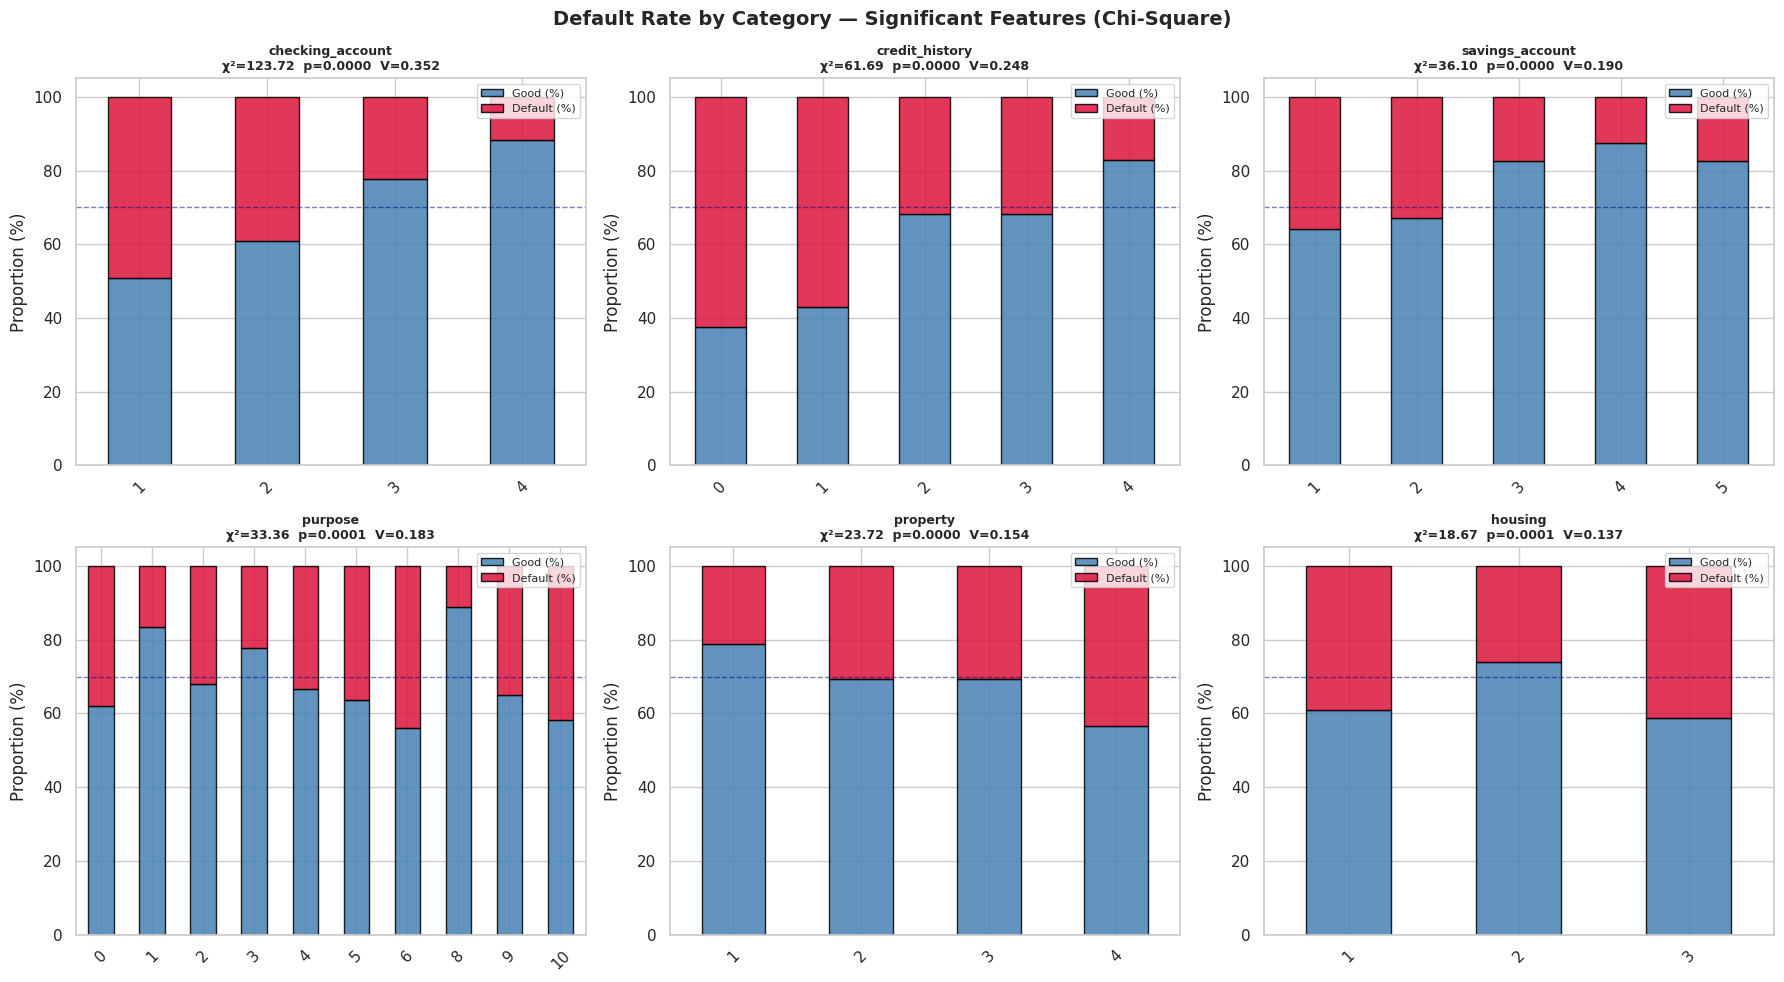

In [12]:
# Plot top 6 significant categorical features
sig_cats = chi2_df[chi2_df['Reject H0']].nlargest(6, 'Cramér V')['Feature'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(sig_cats):
    ct = pd.crosstab(data[col], data['target'], normalize='index') * 100
    ct.columns = ['Good (%)', 'Default (%)']
    ct.plot(kind='bar', stacked=True, ax=axes[i],
            color=['steelblue', 'crimson'], alpha=0.85, edgecolor='black')

    row = chi2_df[chi2_df['Feature'] == col].iloc[0]
    axes[i].set_title(
        f'{col}\nχ²={row["χ²-stat"]:.2f}  p={row["p-value"]:.4f}  V={row["Cramér V"]:.3f}',
        fontweight='bold', fontsize=9
    )
    axes[i].set_ylabel('Proportion (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].axhline(70, color='navy', linestyle='--', linewidth=1, alpha=0.5)
    axes[i].legend(loc='upper right', fontsize=8)

plt.suptitle('Default Rate by Category — Significant Features (Chi-Square)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9 Complete Hypothesis Testing Summary Table

In [13]:
print('=' * 90)
print('HYPOTHESIS TESTING — COMPLETE SUMMARY')
print('=' * 90)

print('\n NUMERIC FEATURES (Mann-Whitney U Test)\n')
print(f'{"Feature":<22} {"p-value":>10} {"Significant?":>14} {"Effect r":>10} {"Effect Size"}')
print('-' * 70)
for _, row in mw_df.iterrows():
    sig = ' YES' if row['Reject H0'] else ' NO'
    print(f'{row["Feature"]:<22} {row["p-value"]:>10.4f} {sig:>14} {row["Effect r"]:>10.4f}   {row["Effect Size"]}')

print('\n\n CATEGORICAL FEATURES (Chi-Square Test)\n')
print(f'{"Feature":<22} {"p-value":>10} {"Significant?":>14} {"Cramér V":>10} {"Effect Size"}')
print('-' * 70)
for _, row in chi2_df.sort_values('Cramér V', ascending=False).iterrows():
    sig = ' YES' if row['Reject H0'] else ' NO'
    print(f'{row["Feature"]:<22} {row["p-value"]:>10.4f} {sig:>14} {row["Cramér V"]:>10.4f}   {row["Effect Size"]}')

total_features = len(mw_df) + len(chi2_df)
sig_features   = mw_df['Reject H0'].sum() + chi2_df['Reject H0'].sum()
print(f'\n\n RESULT: {sig_features}/{total_features} features are statistically significant at α=0.05')

HYPOTHESIS TESTING — COMPLETE SUMMARY

 NUMERIC FEATURES (Mann-Whitney U Test)

Feature                   p-value   Significant?   Effect r Effect Size
----------------------------------------------------------------------
duration_months            0.0000            YES     0.2572   Small
credit_amount              0.0059            YES     0.1097   Small
age                        0.0003            YES    -0.1426   Small
installment_rate           0.0199            YES     0.0868   Negligible
residence_years            0.9358             NO     0.0030   Negligible


 CATEGORICAL FEATURES (Chi-Square Test)

Feature                   p-value   Significant?   Cramér V Effect Size
----------------------------------------------------------------------
checking_account           0.0000            YES     0.3517   Medium
credit_history             0.0000            YES     0.2484   Small
savings_account            0.0000            YES     0.1900   Small
purpose                    0.0001   

## 10 Effect Size Visualization

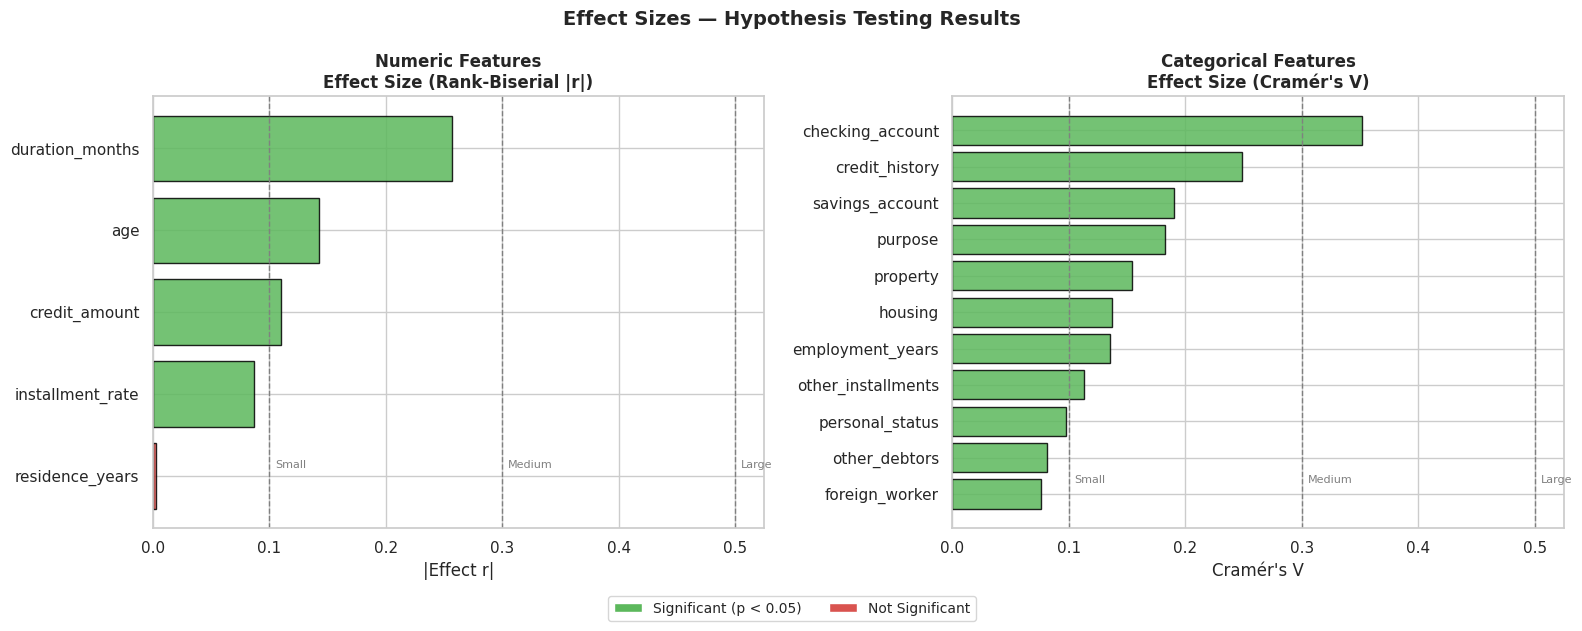

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Numeric — Effect Size (|r|)
mw_plot = mw_df.copy()
mw_plot['|Effect r|'] = mw_plot['Effect r'].abs()
mw_plot = mw_plot.sort_values('|Effect r|', ascending=True)
colors_mw = ['#5cb85c' if r else '#d9534f' for r in mw_plot['Reject H0']]
axes[0].barh(mw_plot['Feature'], mw_plot['|Effect r|'],
             color=colors_mw, edgecolor='black', alpha=0.85)
for xv, lbl in [(0.1,'Small'), (0.3,'Medium'), (0.5,'Large')]:
    axes[0].axvline(xv, linestyle='--', color='gray', linewidth=1)
    axes[0].text(xv+0.005, 0.1, lbl, fontsize=8, color='gray')
axes[0].set_title('Numeric Features\nEffect Size (Rank-Biserial |r|)', fontweight='bold')
axes[0].set_xlabel('|Effect r|')

# Categorical — Cramér's V
chi2_plot = chi2_df.sort_values('Cramér V', ascending=True)
colors_chi = ['#5cb85c' if r else '#d9534f' for r in chi2_plot['Reject H0']]
axes[1].barh(chi2_plot['Feature'], chi2_plot['Cramér V'],
             color=colors_chi, edgecolor='black', alpha=0.85)
for xv, lbl in [(0.1,'Small'), (0.3,'Medium'), (0.5,'Large')]:
    axes[1].axvline(xv, linestyle='--', color='gray', linewidth=1)
    axes[1].text(xv+0.005, 0.3, lbl, fontsize=8, color='gray')
axes[1].set_title('Categorical Features\nEffect Size (Cramér\'s V)', fontweight='bold')
axes[1].set_xlabel("Cramér's V")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#5cb85c', label='Significant (p < 0.05)'),
    Patch(facecolor='#d9534f', label='Not Significant')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.suptitle('Effect Sizes — Hypothesis Testing Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 11 Save Results

In [15]:
# Save hypothesis testing results
mw_df.to_csv('hypothesis_numeric_results.csv', index=False)
chi2_df.to_csv('hypothesis_categorical_results.csv', index=False)

# Final confirmed feature list (significant features only)
confirmed_numeric = mw_df[mw_df['Reject H0']]['Feature'].tolist()
confirmed_categorical = chi2_df[chi2_df['Reject H0']]['Feature'].tolist()
confirmed_all = confirmed_numeric + confirmed_categorical

print('Results saved')
print(f'\n CONFIRMED SIGNIFICANT FEATURES ({len(confirmed_all)} total):')
print(f'   Numeric     : {confirmed_numeric}')
print(f'   Categorical : {confirmed_categorical}')
print(f'\nThese features will be used in Phase 3: Logistic Regression')

Results saved

 CONFIRMED SIGNIFICANT FEATURES (15 total):
   Numeric     : ['duration_months', 'credit_amount', 'age', 'installment_rate']
   Categorical : ['checking_account', 'credit_history', 'purpose', 'savings_account', 'employment_years', 'personal_status', 'other_debtors', 'property', 'other_installments', 'housing', 'foreign_worker']

These features will be used in Phase 3: Logistic Regression


## 12 Phase 2 Summary

**What we did:**
- Checked normality using Shapiro-Wilk before choosing tests
- Applied Mann-Whitney U for numeric features (non-parametric)
- Applied Chi-Square for categorical features
- Calculated effect sizes (not just p-values)
- Interpreted results in business language
- Confirmed final feature list for modeling

---

**Key Interview Talking Points:**

- *"I didn't just use t-tests blindly — I first checked normality with Shapiro-Wilk and used Mann-Whitney U since financial data is rarely normal."*

- *"p-values alone are misleading — a tiny p-value with a negligible effect size means nothing practically. I always report both."*

- *"Cramér's V showed checking_account has both statistical significance AND a large practical effect — that's a genuinely important feature, not a fluke."*

- *"Hypothesis testing gave me statistical confidence before model building — I'm not just throwing features into XGBoost and hoping."*

---
**Next Phase:** Logistic Regression — the statistical way using `statsmodels`, with coefficient interpretation, odds ratios, and assumption testing.